Import Libraries

In [ ]:
import numpy as np                  # NumPy: for numerical operations and working with arrays
import pandas as pd                 # Pandas: for loading, cleaning, and manipulating datasets
import matplotlib.pyplot as plt     # Matplotlib: for creating basic plots and charts
import seaborn as sns               # Seaborn: for advanced and statistical data visualization

Dataset Loading

sep='\t' means the file is tab-separated — each column is separated by a tab character instead of a comma.


In [157]:
data = pd.read_csv("House_Price_dataset.csv", sep='\t')

print(data.shape)
data.head()

(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02-05-2014 00:00,313000.0,3,1.50,1340.0,7912.0,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02-05-2014 00:00,2384000.0,5,2.50,3650.0,9050.0,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,02-05-2014 00:00,342000.0,3,2.00,1930.0,11947.0,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02-05-2014 00:00,420000.0,3,2.25,2000.0,8030.0,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02-05-2014 00:00,550000.0,4,2.50,1940.0,10500.0,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [158]:
# --- Full Feature Engineering (Safe & Clean) ---

# 1️⃣ Ensure date is datetime and extract year/month
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y %H:%M', errors='coerce')
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

# 2️⃣ House age (from year built)
data['house_age'] = data['year'] - data['yr_built']

# 3️⃣ Was renovated (binary)
data['was_renovated'] = data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# 4️⃣ Total square footage
data['total_sqft'] = data['sqft_living'] + data['sqft_basement']

# 5️⃣ Bathrooms per bedroom
data['bath_per_bed'] = data['bathrooms'] / (data['bedrooms'] + 1)

# 6️⃣ Log transform of lot size
data['log_sqft_lot'] = np.log1p(data['sqft_lot'])

# --- New Feature Engineering ---

# 7️⃣ ZIP code prefix
data['zip_prefix'] = data['statezip'].astype(str).str[:3]

# 8️⃣ Years since renovation (if renovated, else house_age)
data['years_since_renovation'] = data.apply(
    lambda x: x['year'] - x['yr_renovated'] if x['yr_renovated'] > 0 else x['house_age'], axis=1
)

# 9️⃣ Lot usage ratio (total living sqft / lot sqft)
data['lot_usage_ratio'] = data['total_sqft'] / data['sqft_lot']

# 🔟 Interaction features
data['bed_bath_interaction'] = data['bedrooms'] * data['bathrooms']
data['floors_sqft_interaction'] = data['floors'] * data['total_sqft']

# 1️⃣1️⃣ Huge lot flag (binary)
data['huge_lot'] = (data['sqft_lot'] > 20000).astype(int)

# 1️⃣2️⃣ Drop unnecessary columns
data = data.drop(['street', 'country', 'date'], axis=1)

# ✅ Feature engineering complete
print("Feature engineering done. Columns now include:")
print(data.columns)

Feature engineering done. Columns now include:
Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip', 'year', 'month',
       'house_age', 'was_renovated', 'total_sqft', 'bath_per_bed',
       'log_sqft_lot', 'zip_prefix', 'years_since_renovation',
       'lot_usage_ratio', 'bed_bath_interaction', 'floors_sqft_interaction',
       'huge_lot'],
      dtype='str')


In [159]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   price                    4596 non-null   float64
 1   bedrooms                 4600 non-null   int64  
 2   bathrooms                4600 non-null   float64
 3   sqft_living              4599 non-null   float64
 4   sqft_lot                 4598 non-null   float64
 5   floors                   4600 non-null   float64
 6   waterfront               4600 non-null   int64  
 7   view                     4600 non-null   int64  
 8   condition                4600 non-null   int64  
 9   sqft_above               4600 non-null   int64  
 10  sqft_basement            4600 non-null   int64  
 11  yr_built                 4600 non-null   int64  
 12  yr_renovated             4600 non-null   int64  
 13  city                     4598 non-null   str    
 14  statezip                 4600 non-n

In [160]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,house_age,was_renovated,total_sqft,bath_per_bed,log_sqft_lot,years_since_renovation,lot_usage_ratio,bed_bath_interaction,floors_sqft_interaction,huge_lot
count,4.596000e+03,4600.000000,4600.000000,4599.000000,4.598000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,...,4599.000000,4600.000000,4599.000000,4600.000000,4598.000000,4599.000000,4597.000000,4600.000000,4599.000000,4600.000000
mean,5.521365e+05,3.400870,2.160815,2139.275060,1.485535e+04,1.512065,0.007174,0.240652,3.451739,1826.930870,...,43.207436,0.405435,2451.291803,0.491159,9.002330,28.956730,0.373431,7.737446,3821.148837,0.117826
std,5.640223e+05,0.908848,0.783781,963.299307,3.589187e+04,0.538288,0.084404,0.778405,0.677230,862.578982,...,29.732050,0.491029,1242.294714,0.151334,0.910651,26.866805,0.308131,4.353345,2638.874771,0.322437
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,370.000000,0.000000,6.459904,0.000000,0.002123,0.000000,370.000000,0.000000
25%,3.239583e+05,3.000000,1.750000,1460.000000,5.001000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,...,17.000000,0.000000,1545.000000,0.375000,8.517593,9.000000,0.168276,5.000000,1950.000000,0.000000
50%,4.610000e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,...,38.000000,0.000000,2260.000000,0.500000,8.946896,20.000000,0.292035,7.500000,3280.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100000e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,...,63.000000,1.000000,3040.000000,0.600000,9.305741,41.000000,0.477778,10.000000,5000.000000,0.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,...,114.000000,1.000000,17670.000000,1.125000,13.887104,114.000000,2.865090,56.000000,53010.000000,1.000000


In [161]:
data.isnull().sum()

price                      4
bedrooms                   0
bathrooms                  0
sqft_living                1
sqft_lot                   2
floors                     0
waterfront                 0
view                       0
condition                  0
sqft_above                 0
sqft_basement              0
yr_built                   0
yr_renovated               0
city                       2
statezip                   0
year                       1
month                      1
house_age                  1
was_renovated              0
total_sqft                 1
bath_per_bed               0
log_sqft_lot               2
zip_prefix                 0
years_since_renovation     1
lot_usage_ratio            3
bed_bath_interaction       0
floors_sqft_interaction    1
huge_lot                   0
dtype: int64

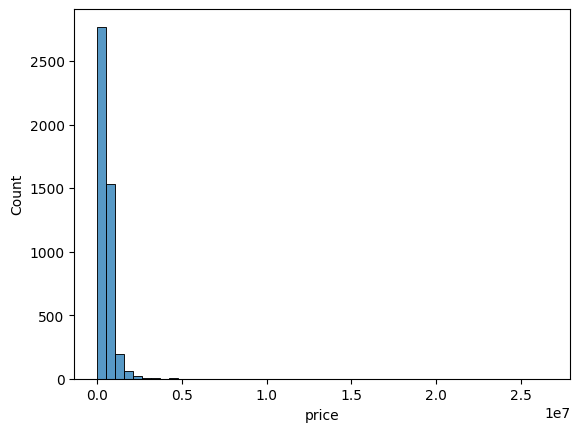

In [162]:
import matplotlib.pyplot as plt

sns.histplot(data['price'], bins=50)
plt.show()


In [163]:
data= data.dropna(subset= ['price'])

In [164]:
data['price'].isnull().sum()
X=data.drop(columns= 'price')

In [165]:
X= data.drop(columns='price')
y = data['price']

In [166]:
print(X)

      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0            3       1.50       1340.0    7912.0     1.5           0     0   
1            5       2.50       3650.0    9050.0     2.0           0     4   
2            3       2.00       1930.0   11947.0     1.0           0     0   
3            3       2.25       2000.0    8030.0     1.0           0     0   
4            4       2.50       1940.0   10500.0     1.0           0     0   
...        ...        ...          ...       ...     ...         ...   ...   
4594         3       2.50       1610.0    7223.0     2.0           0     0   
4595         3       1.75       1510.0    6360.0     1.0           0     0   
4596         3       2.50       1460.0    7573.0     2.0           0     0   
4597         3       2.50       3010.0    7014.0     2.0           0     0   
4599         3       2.50       1490.0    8102.0     2.0           0     0   

      condition  sqft_above  sqft_basement  ...  was_renovated 

In [167]:
print(y)

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4594    2.106143e+05
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4599    2.206000e+05
Name: price, Length: 4596, dtype: float64


In [168]:
data.isnull().values.any()  # Check if there are any missing values in the entire dataset
                            # Returns True if there is at least one missing value, False if none

np.True_

In [169]:
print("NaN in X:", X.isnull().sum() .sum())
print("NaN in y:", y.isnull().sum())

NaN in X: 9
NaN in y: 0


In [170]:
data[data.isnull().any(axis=1)] # Display all rows in the dataset that contain at least one missing value
                                # axis=1 checks across columns for each row
                                

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,was_renovated,total_sqft,bath_per_bed,log_sqft_lot,zip_prefix,years_since_renovation,lot_usage_ratio,bed_bath_interaction,floors_sqft_interaction,huge_lot
4574,0.0000,3,1.00,1520.0,9030.0,1.0,0,0,3,1520,...,1,1520.0,0.250000,9.108418,WA,13.0,0.168328,3.0,1520.0,0
4577,287919.7826,2,1.00,870.0,4600.0,1.0,0,0,4,870,...,1,870.0,0.333333,8.434029,WA,NaN,0.189130,2.0,870.0,0
4579,454790.0000,2,1.75,1990.0,NaN,1.0,0,0,5,1090,...,1,2890.0,0.583333,NaN,WA,16.0,NaN,3.5,2890.0,0
4597,416904.1667,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,...,0,3010.0,0.625000,8.855806,WA,5.0,0.429142,7.5,6020.0,0


In [171]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

cat_cols = X.select_dtypes(include=['object','string']).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'year', 'month', 'house_age', 'was_renovated', 'total_sqft', 'bath_per_bed', 'log_sqft_lot', 'years_since_renovation', 'lot_usage_ratio', 'bed_bath_interaction', 'floors_sqft_interaction', 'huge_lot']
Categorical: ['city', 'statezip', 'zip_prefix']


Missing Values

In [172]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# 1. Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit imputer ONLY on training set
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])


cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

# 3. Transform test set using the same imputer
X_test[num_cols] = num_imputer.transform(X_test[num_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [173]:
print(X)

      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0            3       1.50       1340.0    7912.0     1.5           0     0   
1            5       2.50       3650.0    9050.0     2.0           0     4   
2            3       2.00       1930.0   11947.0     1.0           0     0   
3            3       2.25       2000.0    8030.0     1.0           0     0   
4            4       2.50       1940.0   10500.0     1.0           0     0   
...        ...        ...          ...       ...     ...         ...   ...   
4594         3       2.50       1610.0    7223.0     2.0           0     0   
4595         3       1.75       1510.0    6360.0     1.0           0     0   
4596         3       2.50       1460.0    7573.0     2.0           0     0   
4597         3       2.50       3010.0    7014.0     2.0           0     0   
4599         3       2.50       1490.0    8102.0     2.0           0     0   

      condition  sqft_above  sqft_basement  ...  was_renovated 

In [174]:
print(X_train)

      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
1455       7.0       4.00       3150.0   34830.0     1.0         0.0   0.0   
3189       3.0       1.50       1460.0    8710.0     1.0         0.0   0.0   
1554       4.0       2.75       1240.0    3867.0     1.0         0.0   0.0   
3850       4.0       1.75       2400.0    7700.0     1.5         0.0   0.0   
2778       4.0       2.50       2290.0    6738.0     2.0         0.0   0.0   
...        ...        ...          ...       ...     ...         ...   ...   
4426       3.0       1.00       1180.0    5002.0     1.5         0.0   0.0   
466        4.0       2.00       2520.0    6000.0     1.0         0.0   0.0   
3092       3.0       1.00       1150.0    8145.0     1.0         0.0   0.0   
3772       2.0       1.00        910.0    2002.0     1.5         0.0   0.0   
860        2.0       1.00       1490.0    3825.0     1.0         0.0   0.0   

      condition  sqft_above  sqft_basement  ...  was_renovated 

In [175]:
print(y_train)

1455    999000.0000
3189    324950.0000
1554    400000.0000
3850    389000.0000
2778    570000.0000
           ...     
4426    282508.8889
466     875000.0000
3092    290000.0000
3772    600000.0000
860     475000.0000
Name: price, Length: 3676, dtype: float64


In [176]:
print(X_test)

      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
1393       4.0       1.00       2100.0    9288.0     1.0         0.0   0.0   
2936       3.0       2.25       1940.0   11612.0     1.0         0.0   0.0   
1880       4.0       2.25       2500.0    8500.0     1.0         0.0   0.0   
505        4.0       1.75       2350.0   11914.0     1.0         0.0   0.0   
869        4.0       1.00       1660.0    4690.0     1.5         0.0   0.0   
...        ...        ...          ...       ...     ...         ...   ...   
2520       4.0       2.75       2450.0    4187.0     2.0         0.0   2.0   
1330       4.0       2.50       2920.0    7200.0     1.0         0.0   3.0   
4121       3.0       1.00       1320.0    5000.0     1.5         0.0   0.0   
643        5.0       2.00       1700.0    7314.0     1.0         0.0   0.0   
4566       3.0       2.50       1530.0    3210.0     1.5         0.0   0.0   

      condition  sqft_above  sqft_basement  ...  was_renovated 

In [177]:
print(y_test)

1393    3.050000e+05
2936    3.599500e+05
1880    6.460000e+05
505     8.500000e+05
869     5.600000e+05
            ...     
2520    7.350000e+05
1330    1.050000e+06
4121    2.015000e+05
643     3.375000e+05
4566    5.586538e+05
Name: price, Length: 920, dtype: float64


Data preprocessing

In [178]:
# Import necessary preprocessing tools
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

#numeric columns
num_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
            'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
            'yr_built', 'yr_renovated', 'year', 'month','house_age', 'total_sqft', 'bath_per_bed', 'log_sqft_lot', 'was_renovated', 'years_since_renovation', 'lot_usage_ratio', 'bed_bath_interaction',
    'floors_sqft_interaction']


# Categorical columns
cat_cols = ['city', 'statezip', 'zip_prefix', 'huge_lot']
                                                # Create a ColumnTransformer to preprocess data:
                                                # - Standardize numeric columns using StandardScaler
                                                 # - One-hot encode categorical columns (ignoring unknown categories)
ct_linear = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
          ('cat', OneHotEncoder(handle_unknown='ignore',  sparse_output=False), cat_cols) #With handle_unknown='ignore' → [0, 0] (no error, safe) ✅
    ]
)

ct_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),  # NO scaling ❗
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)





In [179]:
print(X)

      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0            3       1.50       1340.0    7912.0     1.5           0     0   
1            5       2.50       3650.0    9050.0     2.0           0     4   
2            3       2.00       1930.0   11947.0     1.0           0     0   
3            3       2.25       2000.0    8030.0     1.0           0     0   
4            4       2.50       1940.0   10500.0     1.0           0     0   
...        ...        ...          ...       ...     ...         ...   ...   
4594         3       2.50       1610.0    7223.0     2.0           0     0   
4595         3       1.75       1510.0    6360.0     1.0           0     0   
4596         3       2.50       1460.0    7573.0     2.0           0     0   
4597         3       2.50       3010.0    7014.0     2.0           0     0   
4599         3       2.50       1490.0    8102.0     2.0           0     0   

      condition  sqft_above  sqft_basement  ...  was_renovated 

Linear Regression → baseline

Random Forest Regressor → handles large number of features well

XGBoost / LightGBM → for better accuracy

Three Models Import pipeline

In [180]:
from sklearn .pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

In [181]:
linear_model = Pipeline([
     ('preprocess', ct_linear),
    ('regressor', LinearRegression())
])

random_model = Pipeline([
     ('preprocess', ct_tree),
    ('regressor', RandomForestRegressor(n_estimators = 500, max_depth=12, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state = 2))
])

xgb_model = Pipeline([
     ('preprocess', ct_tree),
    ('regressor', xgb.XGBRegressor(n_estimators=800, max_depth=8, learning_rate=0.05, min_child_weight=2, colsample_bytree=0.7, subsample=0.8, random_state=2, eval_metric='rmse'))
])

In [182]:
linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [183]:
random_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [184]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

Model Prediction

In [185]:
y_pred_linear = linear_model.predict(X_test)
y_pred_random = random_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

Evaluation Metrics

In [186]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))


rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Linear Regression RMSE: ${rmse_linear:,.2f}")

print(f"Random Forest RMSE: ${rmse_random:,.2f}")

print(f"XGBoost RMSE: ${rmse_xgb:,.2f}")

Linear Regression RMSE: $251,774.56
Random Forest RMSE: $243,023.71
XGBoost RMSE: $243,637.85


In [187]:
from sklearn.metrics import r2_score

r2_linear = r2_score(y_test, y_pred_linear)
accuracy_linear = r2_linear

r2_random = r2_score(y_test, y_pred_random)
accuracy_random = r2_random

r2_xgb = r2_score(y_test, y_pred_xgb)
accuracy_xgb = r2_xgb


print(f"linear Regression, Accuracy(R2): {accuracy_linear:.2f}")

print(f"Random Forest, Accuracy(R2): {accuracy_random:.2f}")

print(f"XGBoost, Accuracy(R2): {accuracy_xgb:.2f}")


linear Regression, Accuracy(R2): 0.56
Random Forest, Accuracy(R2): 0.59
XGBoost, Accuracy(R2): 0.59


In [188]:
print(accuracy_linear)
print(accuracy_random)
print(accuracy_xgb)

0.5629200320835503
0.5927749047633968
0.5907141423439153


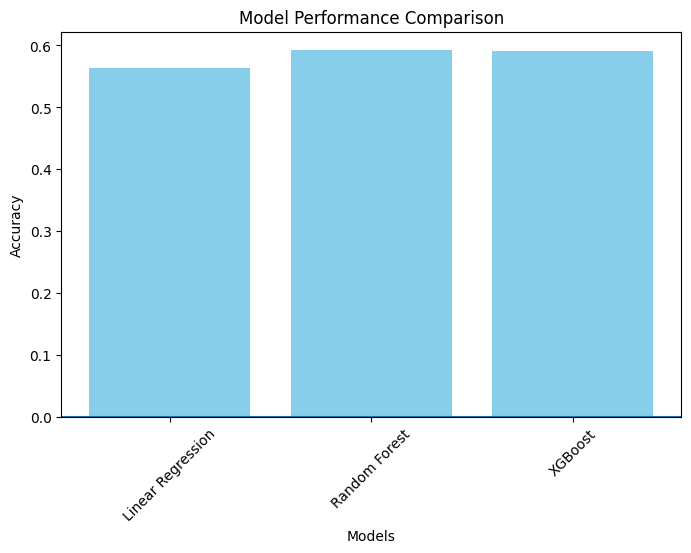

In [189]:
models = [
    "Linear Regression",
    "Random Forest",
    "XGBoost"
]

accuracies = [r2_linear, r2_random, r2_xgb]  # all equal

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color='skyblue')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.axhline(0)  # shows zero baseline
plt.xticks(rotation=45)
plt.show()

In [190]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Define your models (assuming you already have these pipelines)
models = {
    "Linear Regression": linear_model,
    "Random Forest": random_model,
    "XGBoost": xgb_model
}

# Dictionary to store CV results
cv_results = {}

# Perform 5-fold cross-validation for each model
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, 
                             scoring='r2', cv=5)  # cv=5 folds
    cv_results[name] = scores
    print(f"{name}: R² mean={scores.mean():.3f}, std={scores.std():.3f}")

Linear Regression: R² mean=0.454, std=0.238
Random Forest: R² mean=0.397, std=0.222
XGBoost: R² mean=0.242, std=0.161


Visualizati0on

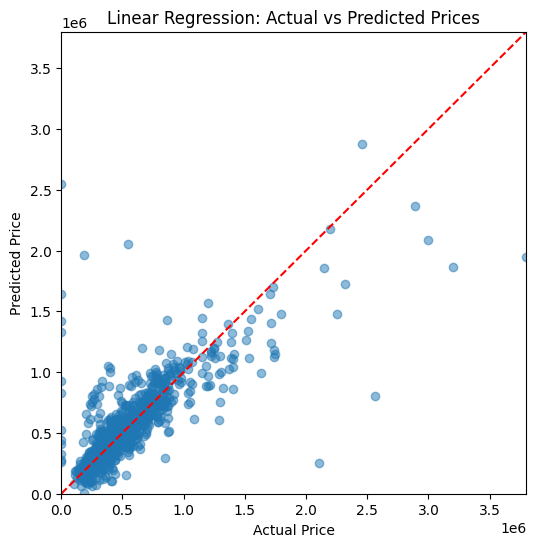

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")

plt.show()

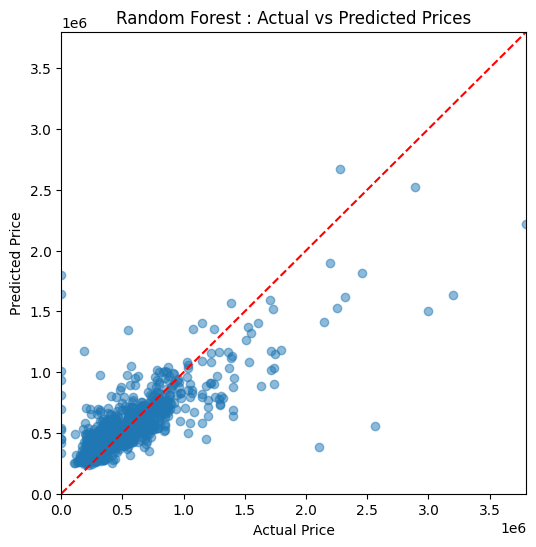

In [192]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_random, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest : Actual vs Predicted Prices")

plt.show()

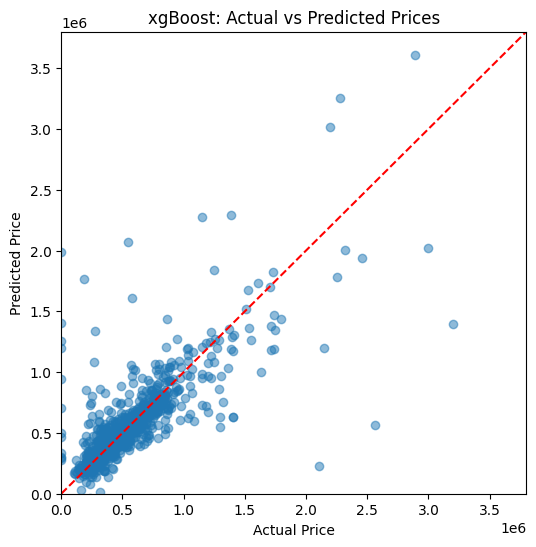

In [193]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("xgBoost: Actual vs Predicted Prices")

plt.show()

In [194]:
# Store model results
models = {
    "Linear Regression": r2_linear,
    "Random Forest": r2_random,
    "XGBoost": r2_xgb
}

# Find best model
best_model = max(models, key=models.get)

print("Best Model:", best_model)
print("Accuracy (R²):", models[best_model])

Best Model: Random Forest
Accuracy (R²): 0.5927749047633968
